# FINAL PROJECT TITLE
#### By: Natasha Strauss (2703184), Gloria Wen (#), and Alex (#)

## Introduction

A  markdown  cell  with  1-2  paragraphs  that  summarize  the  main  goals  of  the 
project. Imagine you are giving a report to someone who is not your professor. 
The first paragraph should briefly describe what the topic is, what data analysis 
question you’re interested in, and why it is relevant. The introduction should end 
with a high-level summary of the results and the coming structure of the project. 
Try to make the text self-contained, intended for someone who isn’t familiar with 
Formula 1/FIFA/NFL/U.S. politics/another topic or the dataset being used

## Data Description

Write a markdown cell of 1 paragraph describing which dataset tables (among 
the multiple options) you will be using. State what each relevant row represents, 
how many observations are contained in each table, and a brief overview of the 
of the data that is contained there:

In [10]:
# Import any necessary libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import the data. 
results = pd.read_csv("1-Formula_One/constructor_results.csv")
standings = pd.read_csv("1-Formula_One/constructor_standings.csv")
constructors = pd.read_csv("1-Formula_One/constructors.csv")

# If necessary, do any calculations for counting the number of rows, etc. 

# Any code output that you leave in the final notebook will be seen by the 
# reader  of  the  report.  So,  it  should  be  formatted  nicely  as  part  of  the 
# presentation or removed.

Write a paragraph in markdown describing any merging procedures:

In [ ]:
# Include code for merging

# drivers

Write a paragraph in markdown summarizing any data cleaning procedures: 

In [ ]:
# Include code for data cleaning.

Write a paragraph describing your main columns: 

In [ ]:
# Compute a table of descriptive statistics for the relevant columns of the 
# merged dataset that you’re interested. Again, it is part of the presentation 
# so make sure it is formatted (e.g. round to a smaller number of digits). 
# Avoid showing descriptive statistics of columns you will not be using in 
# your analysis. Try to be selective. The idea is to do a deeper analysis of a 
# few columns rather than to do a lot. 

## Results

This  should  contain  a  combination  of  code  to  produce  tables/plots  and 
markdown text explaining what the findings are. 
Be creative! The idea is to understand the relationship between different sets of 
columns to answer an interesting question about the data. 

In [ ]:
#lalala imports
results = pd.read_csv('1-Formula_One/constructor_results.csv')
standings = pd.read_csv('1-Formula_One/constructor_standings.csv')
constructors = pd.read_csv('1-Formula_One/constructors.csv')
# bro idk i think im gonna merge sum stuff
#ok wait actually i wanna do things by constructors on a season or year wide level because on a racewide level its more noisy
#im gonna take the year variable from the races dataset and pop it into our dataset
races = pd.read_csv('1-Formula_One/races.csv')
results2 = pd.merge(results, races[['raceId', 'year']], on='raceId')
# aggregate ts woohoo
results_agg= (results2.groupby(['constructorId', 'year'], as_index=False) # as index to keep constructor id and year as columns
              .agg(mean_points = ('points','mean'),
                          sd_points =   ('points','std'),
                          min_points =  ('points','min'),
                          max_points =  ('points','max')))
# now i want the info from the constructors thanks
constructors2=pd.merge(left=results_agg, right=constructors, how='left', on='constructorId')
# tryna make season variable so i can merge standings on that - need to get things as string
constructors2['season'] = constructors2['constructorId'].astype(str) + ' ' + constructors2['year'].astype(str)
# now i need to make the season variable in standings so imma merge w races on raceid
standings2 = pd.merge(left=standings, right=races[['raceId', 'year']], how='left', on='raceId')
standings2['season'] = standings2['constructorId'].astype(str) + ' ' + standings2['year'].astype(str)

# now im gonna merge constructors 2 and standings 2
df=pd.merge(left=standings2, right=constructors2[['mean_points', 'sd_points', 'constructorRef', 'name', 'nationality','season']], 
            how='left', on='season')

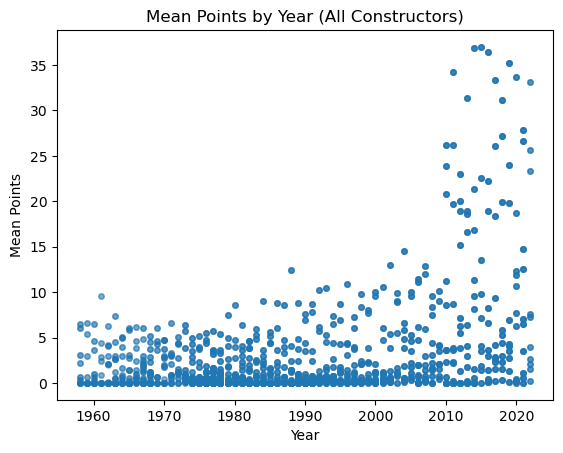

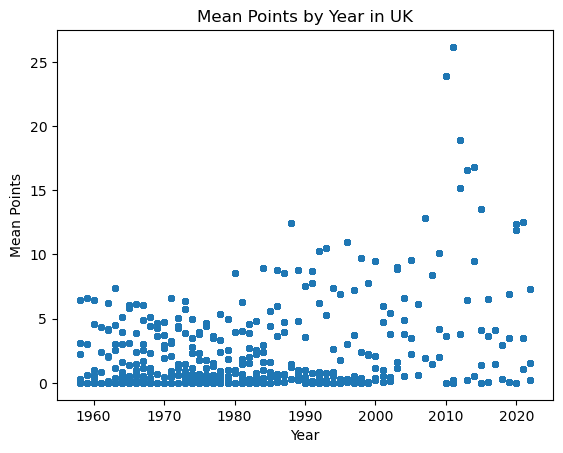

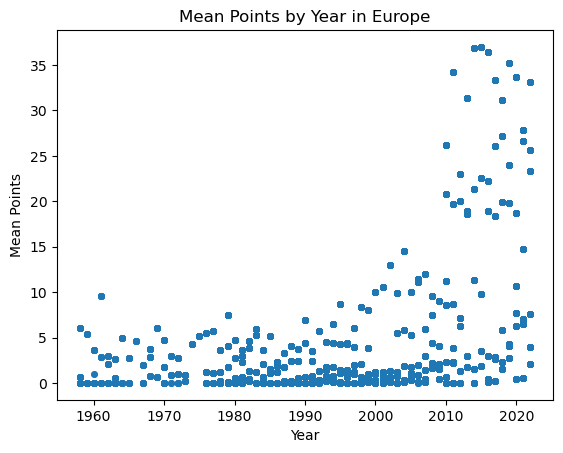

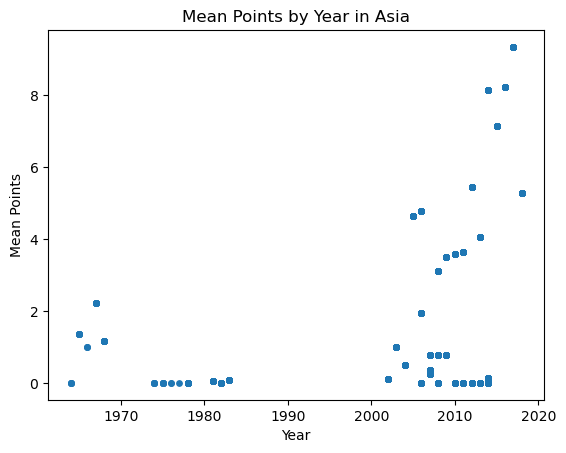

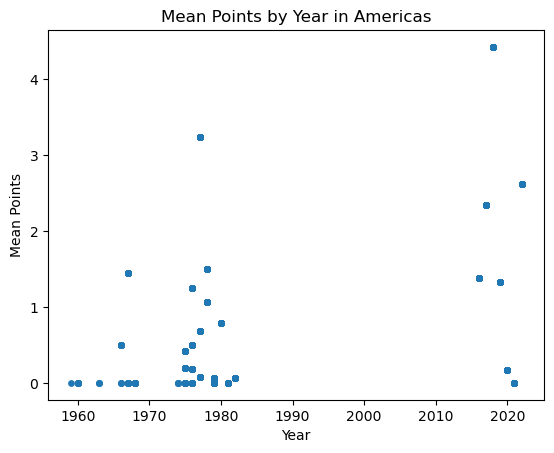

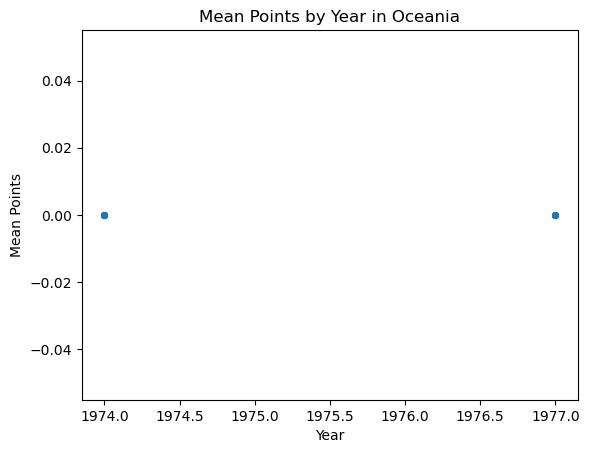

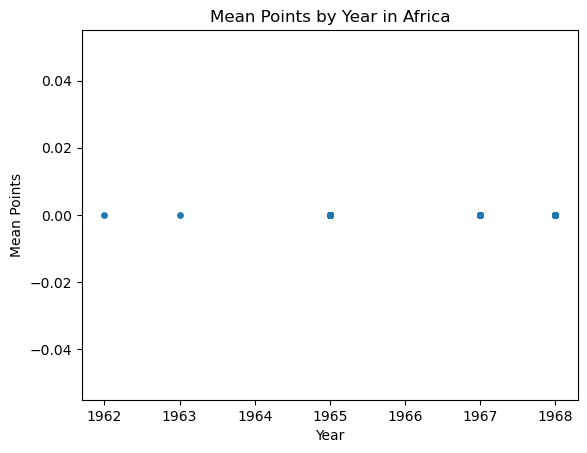

In [ ]:
# Awesome now i think im gonna look at nationalities
constructors['nationality'].value_counts()
# Brits dominate F1 so isolate them and then break the rest up by continent
# define func to sort by region
def region(nationality):
    if nationality == 'British':
        return 'UK'
    elif nationality in ['Italian','French','German','Swiss','Dutch','Irish',
                         'Austrian','Belgian','Spanish','East German']:
        return 'Europe'
    elif nationality in ['American','Canadian','Mexican','Brazilian']:
        return 'Americas'
    elif nationality in ['Japanese','Malaysian','Russian','Indian','Hong Kong']:
        return 'Asia'
    elif nationality in ['South African','Rhodesian']:
        return 'Africa'
    elif nationality in ['Australian','New Zealander']:
        return 'Oceania'
    else:
        return 'Other'
df['region'] = df['nationality'].apply(region)

#now imma do an overall scatterplot
plt.scatter(df['year'], df['mean_points'], alpha =0.1, s=15)
plt.xlabel('Year')
plt.ylabel('Mean Points')
plt.title('Mean Points by Year (All Constructors)')
plt.show()

#now i wanna see if this is region dependent by doing a for loop
# Get unique regions
list_unique_regions = pd.unique(df["region"])

# For loop scatterplot
for category in list_unique_regions:
    subset = df.query("region == @category")
    plt.figure()
    plt.scatter(x=subset["year"], y=subset["mean_points"], s=15)
    plt.xlabel("Year")
    plt.ylabel("Mean Points")
    plt.title('Mean Points by Year in ' + category)

plt.show()




In [ ]:
# so based on this i wanna focus on uk and europe (reagreggating them) and assess what has contributed to new success
euro_df = df.query("region == 'UK' or region == 'Europe'")

# now maybe i wanna focus on the top 10 performing constructors
# mean points per season - dependent
#  

## Discussion

Provide  a  brief  1-2  paragraph  markdown  cell  summarizing  your  findings. 
Describe the main things you learned from the data.